# Geolocating a viral conflict image: the Karachi Port claim

**Case FR-05** from my dissertation, *Disinformation Patterns Across Regional
Conflicts: A Forensic OSINT Analysis* (UWE Bristol, 2026 — presented at the
Bath Lovelace Colloquium 2026, accepted at RATSIF 2026, Riga).

**The claim.** On 8 May 2025, at the height of the India–Pakistan escalation,
an image circulated on X claiming that INS Vikrant had destroyed Karachi
Port. The primary post alone reached **2.5 million views**, with
ecosystem-wide reach estimated above 4 million.

**The question.** Was this photograph taken where — and when — the caption
says it was?

This notebook walks the verification end to end: preservation, reverse
image tracing, geolocation cross-check, timeline reconstruction, and a
final evidence report with explicit confidence levels. All artifacts are
public and the claim was independently debunked; post identifiers are
anonymised.

## Step 1 — Preserve before you analyse

Nothing gets examined until it's hashed. The SHA-256 below is the digest
recorded at original collection (dissertation Table 15). If anyone —
including me — modifies the file afterwards, re-hashing exposes it.

In [1]:
import sys, os
sys.path.insert(0, "..")   # toolkit lives one level up

from ovt.custody import CustodyLog

DOCUMENTED_SHA256 = "56f36ad6f477e42486fc6cdb3106853991d901d0891231da2c615b5af92993df"
IMAGE_PATH = "fr05_artifact.jfif"   # place the preserved artifact here to re-verify

if os.path.exists(IMAGE_PATH):
    current = CustodyLog.hash_file(IMAGE_PATH)
    print("Current hash :", current)
    print("Documented   :", DOCUMENTED_SHA256)
    print("Integrity    :", "INTACT" if current == DOCUMENTED_SHA256 else "MISMATCH — file altered")
else:
    print("Artifact not present locally — proceeding with documented hash:")
    print(DOCUMENTED_SHA256)

Artifact not present locally — proceeding with documented hash:
56f36ad6f477e42486fc6cdb3106853991d901d0891231da2c615b5af92993df


## Step 2 — Reverse image tracing

Three engines were used deliberately: Google Images, TinEye (which indexes
chronologically — crucial for earliest-date verification) and Yandex.
TinEye returned **576 indexed results, earliest 23 February 2020**. Not
one result linked the image to Pakistan, or to 2025.

In [2]:
import pandas as pd

matches = pd.DataFrame([
    ["BBC News", "Israel-Gaza sees surge of cross-border violence", "bbc.co.uk", "2020-02-23"],
    ["The Guardian", "Israeli strikes in Syria and Gaza kill two Islamic Jihad", "theguardian.com", "2020"],
    ["Al Jazeera", "Israeli air attacks hit Gaza after rocket fire", "aljazeera.com", "2020"],
    ["Qatar News Agency", "(agency wire coverage)", "qna.org.qa", "2020"],
    ["Israel Hayom", "(later republication)", "israelhayom.com", "2021-2022"],
], columns=["Source", "Headline", "Platform", "Earliest indexed"])

matches

,Source,Headline,Platform,Earliest indexed
0,BBC News,Israel-Gaza sees surge of cross-border violence,bbc.co.uk,2020-02-23
1,The Guardian,Israeli strikes in Syria and Gaza kill two Isl...,theguardian.com,2020
2,Al Jazeera,Israeli air attacks hit Gaza after rocket fire,aljazeera.com,2020
3,Qatar News Agency,(agency wire coverage),qna.org.qa,2020
4,Israel Hayom,(later republication),israelhayom.com,2021-2022


Every earliest match converges on one event: **Israeli airstrikes on
Gaza, February 2020** — five years before the claimed event, in a
different conflict, about 2,400 km away.

## Step 3 — The geolocation cross-check

This is the part a caption can't fake. Plot the *claimed* location
against the location the evidence actually supports:

In [3]:
import folium

claimed = (24.8145, 66.9752)    # Karachi Port, Pakistan
actual  = (31.5069, 34.4560)    # Gaza — location of the Feb 2020 strikes

m = folium.Map(location=[28.2, 50.5], zoom_start=4, tiles="CartoDB positron")

folium.Marker(
    claimed, tooltip="CLAIMED: Karachi Port, 8 May 2025",
    icon=folium.Icon(color="red", icon="remove-sign"),
).add_to(m)

folium.Marker(
    actual, tooltip="ACTUAL: Gaza, 23 February 2020 (BBC + 4 outlets)",
    icon=folium.Icon(color="green", icon="ok-sign"),
).add_to(m)

folium.PolyLine([claimed, actual], color="crimson", weight=2, dash_array="8",
                tooltip="~2,400 km between claim and evidence").add_to(m)

m.save("fr05_claim_vs_evidence_map.html")
m

/Users/sahifa/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


One image, one caption, and a **2,400 km, five-year gap** between what
was claimed and what the provenance supports.

## Step 4 — Timeline reconstruction

Matplotlib is building the font cache; this may take a moment.


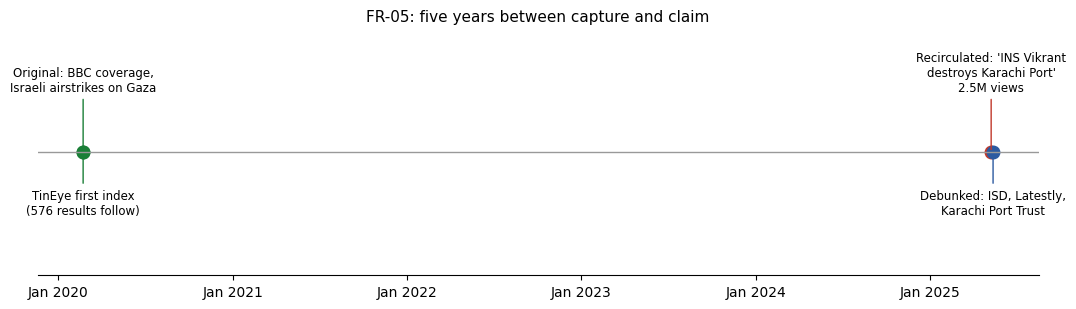

In [4]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

events = [
    (datetime(2020, 2, 23), "Original: BBC coverage,\nIsraeli airstrikes on Gaza", "#1a7f37"),
    (datetime(2020, 2, 23), "TinEye first index\n(576 results follow)", "#1a7f37"),
    (datetime(2025, 5, 8),  "Recirculated: 'INS Vikrant\ndestroys Karachi Port'\n2.5M views", "#c0392b"),
    (datetime(2025, 5, 12), "Debunked: ISD, Latestly,\nKarachi Port Trust", "#2c5aa0"),
]

fig, ax = plt.subplots(figsize=(11, 3.2))
for i, (when, label, colour) in enumerate(events):
    y = 1 if i % 2 == 0 else -1
    ax.annotate(label, (mdates.date2num(when), 0), xytext=(mdates.date2num(when), y),
                textcoords="data", ha="center", fontsize=8.5,
                arrowprops=dict(arrowstyle="-", color=colour))
    ax.plot(when, 0, "o", color=colour, markersize=9)

ax.axhline(0, color="#999", linewidth=1)
ax.set_ylim(-2, 2); ax.set_yticks([])
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.set_title("FR-05: five years between capture and claim", fontsize=11)
for s in ("left", "right", "top"): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.savefig("fr05_timeline.png", dpi=150); plt.show()

## Step 5 — Verdict, with the working shown

In [5]:
from ovt.timestamps import normalise, sequence_check
from ovt.report import EvidenceReport

ordered, _ = sequence_check([
    ("Original publication — BBC, Gaza airstrikes", normalise("2020-02-23T12:00:00Z")),
    ("Claim circulated on X as Karachi Port strike", normalise("2025-05-08 19:00", assume_tz_offset_hours=5)),
    ("Karachi Port Trust confirms port operational", normalise("2025-05-09 12:00", assume_tz_offset_hours=5)),
])

report = EvidenceReport(
    title="FR-05: Karachi Port destruction claim",
    analyst="Sahifa Syed",
    case_ref="FR-05 (dissertation, UWE Bristol 2026)",
)
report.add_artifact("E0001", {
    "file": "karachi_gaza2020.jfif",
    "format": "JFIF image, collected from X",
    "exif_present": False, "capture_time": None,
    "device": None, "software": None, "gps": None,
}, notes=f"SHA-256 at collection: {DOCUMENTED_SHA256}")
report.add_timeline(ordered)

report.add_finding(
    "The image depicts Israeli airstrikes on Gaza, February 2020, not Karachi Port in 2025.",
    confidence="confirmed",
    supporting_evidence=["TinEye earliest index 23 Feb 2020 (576 results)",
                         "BBC, Guardian, Al Jazeera original coverage",
                         "Karachi Port Trust operational confirmation"],
)
report.add_finding(
    "FR-05 is cross-conflict media reuse: content from one conflict repurposed "
    "to assert a military event in another that did not occur.",
    confidence="confirmed",
    supporting_evidence=["Reverse-image convergence", "ISD analysis", "No 2025/Pakistan matches in any engine"],
)

report.save("fr05_report.md")
print(report.render()[:900])

ValueError: Unrecognised timestamp format: '2025-05-08 19:00'

## Method notes and ethics

- **Why three engines?** Indexing differs: Yandex is stronger on Eastern
  European content, TinEye supports chronological sorting, Google has the
  widest coverage. Triangulation, not tool trust.
- **Why log timezone assumptions?** A naive timestamp silently treated as
  UTC can invert a timeline. The toolkit records every assumption so it
  appears in the report rather than in the analyst's head.
- **Ethics.** All material is public and was independently fact-checked;
  identifiers are anonymised; the image is referenced by hash rather than
  re-embedded, to avoid re-amplifying the disinformation itself.

*Toolkit: [OSINT-Investigation-Toolkit](https://github.com/sahifasyed/OSINT-Investigation-Toolkit) — chain-of-custody, timestamps and reporting modules used above.*